# 01 · K-Means as a feature-engineering step

**Question.** Can clustering make a simple classifier better?  
**Method** (Géron, *Hands-On ML*, Ch. 9, "Using Clustering for Preprocessing"): replace each 8×8 image by its distances to *k* K-Means centroids, then train a Logistic Regression on those distances. *k* is a hyperparameter of the **classifier**, so we pick it with cross-validated accuracy, not with inertia or the silhouette score.

The production version of this code lives in `src/unsupervised_mlops/clustering_features.py` and runs inside the Prefect `train-flow`; this notebook is the readable walkthrough.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from unsupervised_mlops import plots  # shared plot style
from unsupervised_mlops.data import load_digits_split
pd.set_option("display.precision", 4)
split = load_digits_split(random_state=42)
split.sizes

{'n_train': 1347, 'n_test': 450}

In [2]:
fig, axes = plt.subplots(2, 10, figsize=(10, 2.3))
for ax, x, y in zip(axes.ravel(), split.X_train, split.y_train):
    plots._digit(ax, x, str(y))
fig.suptitle("Training digits: 8x8 pixels, intensities 0-16", x=0.01, ha="left", fontsize=10, fontweight="bold")
plt.tight_layout()

## Baseline: Logistic Regression on raw pixels

In [3]:
from unsupervised_mlops.clustering_features import make_logreg, build_kmeans_logreg_pipeline
baseline = make_logreg(42).fit(split.X_train, split.y_train)
print(f"baseline test accuracy: {baseline.score(split.X_test, split.y_test):.4f}")

baseline test accuracy: 0.9733


## K-Means (k = 50) → Logistic Regression

The book's first guess is k = 50: there are many ways to write each digit, so 10 clusters would be too few. We try the pipeline with and without a `StandardScaler` on the distance features. Without scaling, the distances are large and strongly correlated, and `lbfgs` can stop at its iteration limit.

In [4]:
for scale in (False, True):
    pipe = build_kmeans_logreg_pipeline(50, 42, n_init=10, scale_distances=scale).fit(split.X_train, split.y_train)
    lr = pipe.named_steps["log_reg"]
    print(f"scale_distances={scale!s:5}  test accuracy={pipe.score(split.X_test, split.y_test):.4f}  "
          f"lbfgs iterations={lr.n_iter_[0]}")

scale_distances=False  test accuracy=0.9756  lbfgs iterations=1268


scale_distances=True   test accuracy=0.9733  lbfgs iterations=44


### Why scaling helps: conditioning
The distance features share a large common offset relative to their spread. That makes the Gram matrix $Z^\top Z$ (with a bias column), which governs the curvature of the loss, badly conditioned.

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
D = KMeans(50, n_init=10, random_state=42).fit_transform(split.X_train)
def cond(Z):
    Z = np.c_[Z, np.ones(len(Z))]
    ev = np.linalg.eigvalsh(Z.T @ Z)
    return ev.max() / ev.min()
print(f"distances: median {np.median(D):.0f}, 5-95th percentile {np.percentile(D, 5):.0f}-{np.percentile(D, 95):.0f}, "
      f"mean per-feature std {D.std(axis=0).mean():.1f}")
print(f"condition number of Z^T Z: raw {cond(D):.2g}  vs  standardised {cond(StandardScaler().fit_transform(D)):.2g}")

distances: median 45, 5-95th percentile 29-56, mean per-feature std 7.7
condition number of Z^T Z: raw 2.2e+08  vs  standardised 4.7e+03


## A fair comparison needs a strong baseline
The book's baseline is Logistic Regression on raw pixels with default settings. The K-Means pipeline gets scaling *and* a 98-value search over *k*, so we also tune a **StandardScaler + Logistic Regression** baseline (C chosen by the same 3-fold CV).

In [6]:
from unsupervised_mlops.clustering_features import tune_scaled_baseline
strong = tune_scaled_baseline(split.X_train, split.y_train, random_state=42)
print(f"strong baseline: C = {strong.best_params_['log_reg__C']}, CV accuracy {strong.best_score_:.4f}, "
      f"test accuracy {strong.score(split.X_test, split.y_test):.4f}")

strong baseline: C = 0.1, CV accuracy 0.9510, test accuracy 0.9711


## Choose k with GridSearchCV (3-fold CV on the training set only)

In [7]:
from unsupervised_mlops.clustering_features import tune_n_clusters, clustering_diagnostics
search = tune_n_clusters(split.X_train, split.y_train, list(range(2, 100)), cv=3, random_state=42,
                         n_init=10, scale_distances=True)
best_k = search.best_params_["kmeans__n_clusters"]
print(f"best k = {best_k}, CV accuracy = {search.best_score_:.4f}, test accuracy = {search.score(split.X_test, split.y_test):.4f}")

best k = 81, CV accuracy = 0.9599, test accuracy = 0.9756


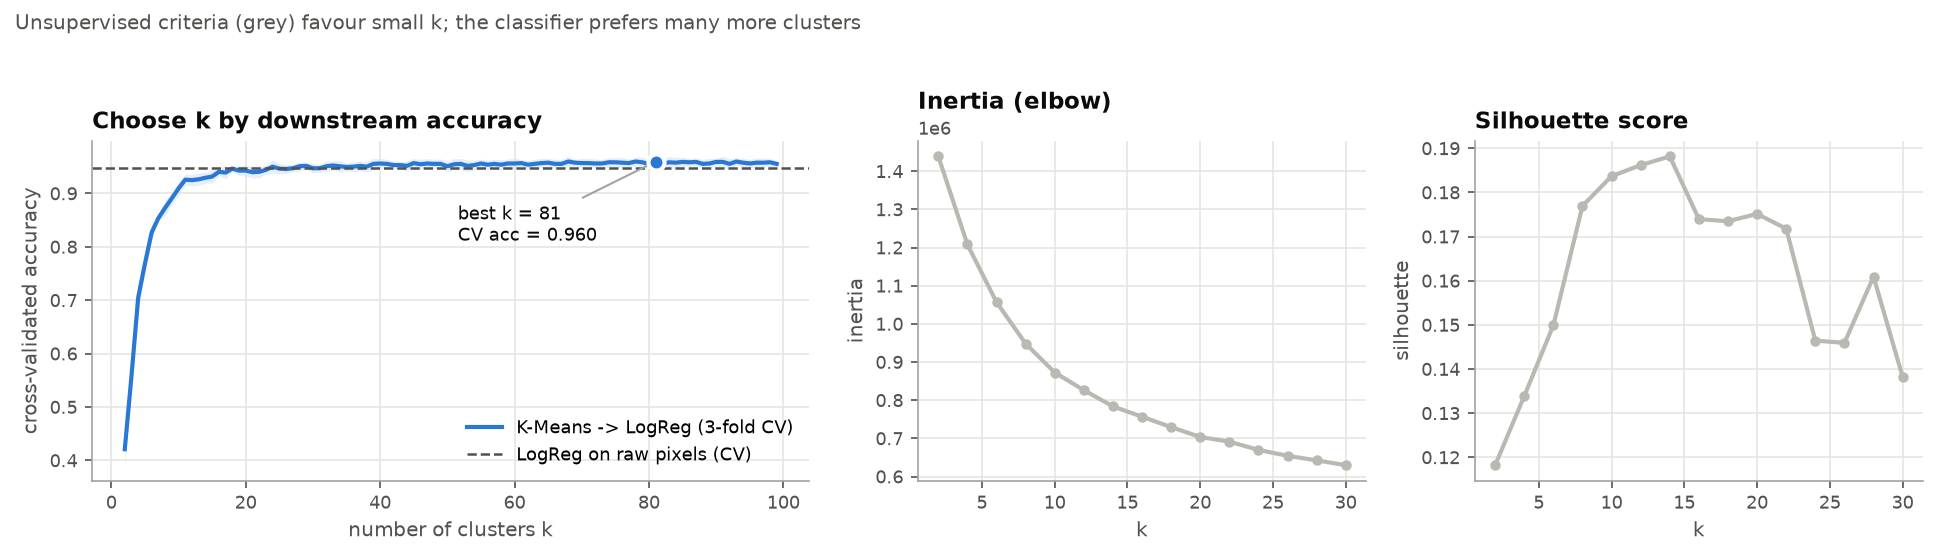

In [8]:
from sklearn.model_selection import cross_val_score
grid = pd.DataFrame({"k": search.cv_results_["param_kmeans__n_clusters"].astype(int),
                     "cv_accuracy": search.cv_results_["mean_test_score"],
                     "cv_std": search.cv_results_["std_test_score"]})
diag = clustering_diagnostics(split.X_train, list(range(2, 31, 2)))
base_cv = cross_val_score(make_logreg(42), split.X_train, split.y_train, cv=3).mean()
plots.plot_k_selection(grid, diag, best_k, base_cv, "/tmp/k_selection.png")
from IPython.display import Image
Image("/tmp/k_selection.png")

**Reading the plot.** The accuracy curve is fairly flat beyond k ≈ 40 and the ±1 std band is wide, so the exact best k is partly noise. The unsupervised criteria (inertia elbow, silhouette peak) point to a much smaller k: they measure how well the clusters fit the data, not how useful the distances are as features.

## How much of the gain is real? Repeat on 5 other random splits

A single 450-image test set is small: one misclassified image is 0.22 percentage points. The pipeline re-tunes k inside each split (coarse grid) so no test data leaks into model selection.

In [9]:
from unsupervised_mlops.clustering_features import robustness_check
rob = robustness_check(seeds=[0, 1, 2, 3, 4], k_values=list(range(10, 100, 10)), scale_distances=True)
rob.round(4)

,seed,baseline_accuracy,tuned_baseline_accuracy,kmeans_logreg_accuracy,best_k,gain_pp,gain_vs_tuned_pp
0,0,0.9533,0.9600,0.9667,80,1.3333,0.6667
1,1,0.9689,0.9800,0.9733,70,0.4444,-0.6667
2,2,0.9444,0.9489,0.9578,90,1.3333,0.8889
3,3,0.9511,0.9578,0.9667,60,1.5556,0.8889
4,4,0.9644,0.9689,0.9822,90,1.7778,1.3333


In [10]:
for col, name in [("baseline_accuracy", "LogReg, raw pixels (book)"), ("tuned_baseline_accuracy", "Scaler + LogReg, C tuned"),
                  ("kmeans_logreg_accuracy", "K-Means -> Scaler -> LogReg")]:
    print(f"{name:30s} {rob[col].mean():.4f} ± {rob[col].std():.4f}")
print(f"gain vs book baseline:   {rob.gain_pp.mean():+.2f} pp (better on {(rob.gain_pp > 0).sum()}/{len(rob)} splits)")
print(f"gain vs strong baseline: {rob.gain_vs_tuned_pp.mean():+.2f} pp (better on {(rob.gain_vs_tuned_pp > 0).sum()}/{len(rob)} splits)")

LogReg, raw pixels (book)      0.9564 ± 0.0100
Scaler + LogReg, C tuned       0.9631 ± 0.0118
K-Means -> Scaler -> LogReg    0.9693 ± 0.0091
gain vs book baseline:   +1.29 pp (better on 5/5 splits)
gain vs strong baseline: +0.62 pp (better on 4/5 splits)


## Takeaways

* K-Means distances are a useful non-linear feature map for a linear model. The gain over the book's baseline is consistent (about +1.3 pp, 5/5 splits). Against a properly tuned, scaled baseline it shrinks to about +0.6 pp, which is real but modest and close to the noise of a 450-image test set.
* Pick *k* by the metric you care about (downstream accuracy), with cross-validation on training data only.
* Scaling the distance features makes Logistic Regression converge and the grid search about 6× faster. The book's unscaled variant is kept as an ablation in `reports/RESULTS.md`.